# Cравнительный анализ **LightRAG vs QDrant** на основе собранных метрик и выводов:

---

## ⚡ Сравнительный анализ

### 1. Latency / Hits / Success

| Система           | latency | hits | success |
| ----------------- | ------- | ---- | ------- |
| LightRAG (hybrid) | 5.12 s  | 4.2  | 1.0     |
| LightRAG (local)  | 10.24 s | 1.6  | 0.6     |
| LightRAG (global) | 7.55 s  | 1.2  | 0.4     |
| QDrant            | 0.106 s | 2.6  | -       |

**Вывод:**

* QDrant — **в 50–100 раз быстрее** LightRAG, даже в режиме hybrid.
* LightRAG hybrid быстро извлекает сущности, но всё равно медленнее QDrant.
* По hits: LightRAG hybrid находит больше ключевых сущностей, QDrant — среднее значение ~2.6 hits, но с низкой latency.

---

### 2. Precision / Recall / F1

| Система           | precision | recall | f1     |
| ----------------- | --------- | ------ | ------ |
| LightRAG (hybrid) | 0.0615    | 0.5571 | 0.1104 |
| LightRAG (local)  | 0.0271    | 0.2000 | 0.0477 |
| LightRAG (global) | 0.0136    | 0.1333 | 0.0246 |
| QDrant            | 0.5200    | 0.4452 | 0.4747 |

**Вывод:**

* **Precision QDrant (~52%)** существенно выше, чем у всех режимов LightRAG (<6%), что говорит о более точной выдаче релевантных текстов.
* **Recall:** LightRAG hybrid выигрывает (~56%), QDrant чуть меньше (~45%).
* **F1-score:** QDrant (~0.475) значительно лучше сбалансирован, LightRAG hybrid — 0.11, local/global ещё ниже.

---

### 3. Практический вывод

**LightRAG:**

* Плюсы:

  * Позволяет строить граф знаний и извлекать сложные связи между сущностями.
  * Гибкие режимы: hybrid, local, global.
* Минусы:

  * Высокая latency, особенно local/global.
  * Низкая precision — много “лишней” информации.
  * Требует качественных промптов и LLM для хорошего извлечения.

**QDrant:**

* Плюсы:

  * Очень быстрая семантическая ретривка (latency ~0.1 сек).
  * Высокая точность (precision 52%).
  * Простая интеграция и масштабируемость.
* Минусы:

  * Не извлекает сложные графовые связи между сущностями.
  * Recall чуть ниже, чем у LightRAG hybrid, но компенсируется высокой speed и precision.

---

### 🔹 Итог: что выбрать

* **Если нужен быстрый, точный и простой retrieval** → QDrant — лучший выбор.
* **Если нужна сложная логика графа и связь между сущностями** → LightRAG имеет смысл, но только при правильно настроенном hybrid-режиме и промптах.
* Для большинства типичных RAG‑систем, где критична скорость и точность retrieval, **QDrant выигрывает**.


/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_51646/1631532984.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df['system'], rotation=45, ha='right')
/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_51646/1631532984.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df['system'], rotation=45, ha='right')
/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_51646/1631532984.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(df['system'], rotation=45, ha='right')


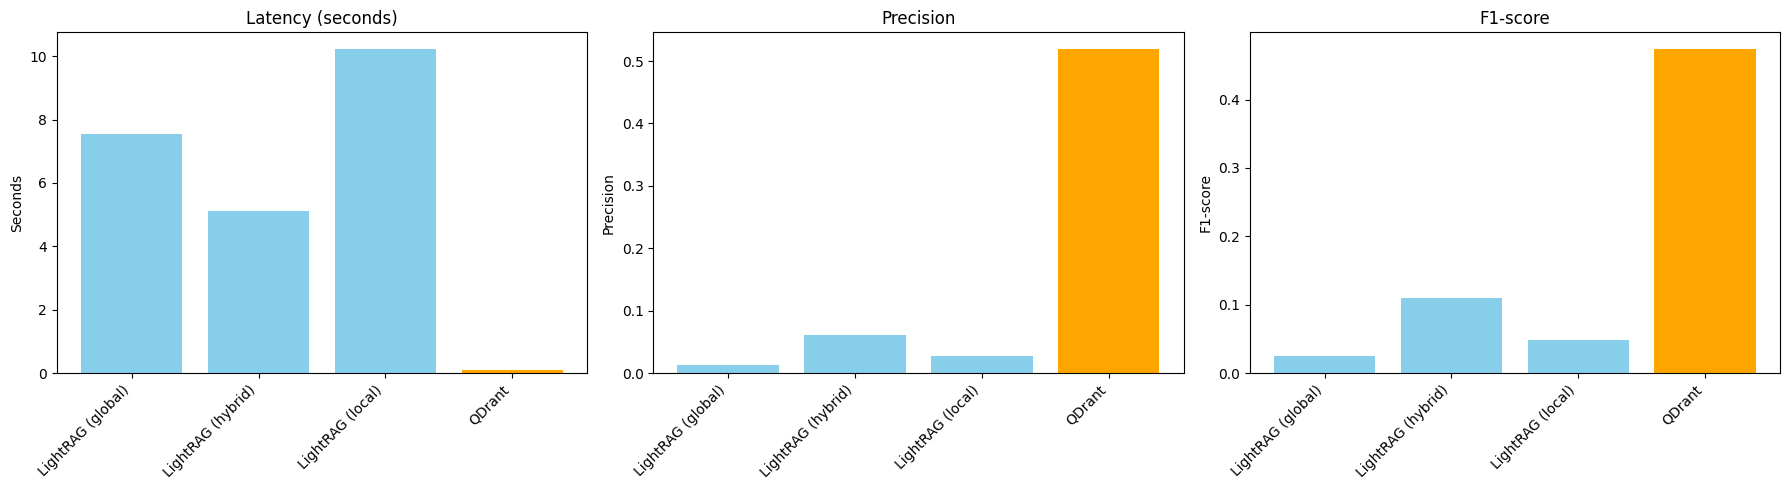

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Метрики LightRAG и QDrant
data = {
    "system": [
        "LightRAG (global)", "LightRAG (hybrid)", "LightRAG (local)", "QDrant"
    ],
    "latency_s": [
        7.55, 5.12, 10.24, 0.106
    ],
    "precision": [
        0.0136, 0.0615, 0.0271, 0.52
    ],
    "recall": [
        0.1333, 0.5571, 0.2, 0.4452
    ],
    "f1": [
        0.0246, 0.1104, 0.0477, 0.4747
    ]
}

df = pd.DataFrame(data)

# --- Построение графиков ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Latency
axes[0].bar(df['system'], df['latency_s'], color=['skyblue', 'skyblue', 'skyblue', 'orange'])
axes[0].set_title("Latency (seconds)")
axes[0].set_ylabel("Seconds")
axes[0].set_xticklabels(df['system'], rotation=45, ha='right')

# 2. Precision
axes[1].bar(df['system'], df['precision'], color=['skyblue', 'skyblue', 'skyblue', 'orange'])
axes[1].set_title("Precision")
axes[1].set_ylabel("Precision")
axes[1].set_xticklabels(df['system'], rotation=45, ha='right')

# 3. F1-score
axes[2].bar(df['system'], df['f1'], color=['skyblue', 'skyblue', 'skyblue', 'orange'])
axes[2].set_title("F1-score")
axes[2].set_ylabel("F1-score")
axes[2].set_xticklabels(df['system'], rotation=45, ha='right')

plt.tight_layout()
plt.show()
